# Inciso 6

### Importación de librerías.

In [1]:
from pathlib import Path
import rasterio
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr, linregress
import pandas as pd
import matplotlib.pyplot as plt

### Función para extraer índices.

In [2]:
def procesar_archivo_indices(ruta):

    ruta = Path(ruta)
    with rasterio.open(ruta) as src:
        cyano = src.read(1).astype("float32")
        ndvi = src.read(2).astype("float32")
        ndwi = src.read(3).astype("float32")
        valid_mask = src.read(4)

    # Píxeles  válidos en las cuatro bandas
    mascara = ((valid_mask == 1) & np.isfinite(cyano) & np.isfinite(ndvi) & np.isfinite(ndwi))


    return {"cyano_mean": np.mean(cyano[mascara]),
            "ndvi_mean": np.mean(ndvi[mascara]),
            "ndwi_mean": np.mean(ndwi[mascara]),
            "n_pixels": mascara.sum()
            }

### Extracción de datos.

In [3]:
DIRECTORIO_DATA = Path("data")

resultados = []

for lago in ["atitlan", "amatitlan"]:

    carpeta = DIRECTORIO_DATA / lago

    archivos = sorted(carpeta.glob(f"{lago}_*_indices.tif"))
    for ruta in archivos:
        fecha = ruta.stem.split("_")[1]
        estadisticas = procesar_archivo_indices(ruta)

        resultados.append({"lago": lago.capitalize(),
                           "fecha": fecha,
                           **estadisticas})

df_indices = pd.DataFrame(resultados)
df_indices["fecha"] = pd.to_datetime(df_indices["fecha"])
df_indices = df_indices.sort_values(["lago", "fecha"]).reset_index(drop=True)
df_indices.head()

,lago,fecha,cyano_mean,ndvi_mean,ndwi_mean,n_pixels
0,Amatitlan,2025-01-28,4.428946,-0.223535,0.460359,36896
1,Amatitlan,2025-04-15,4.528544,-0.103234,0.293362,36473
2,Amatitlan,2025-04-28,4.255443,-0.150284,0.365127,18987
3,Amatitlan,2025-11-24,5.468830,-0.194541,0.421901,18901
4,Amatitlan,2026-01-08,6.688481,-0.103710,0.355152,36928


### Función de correlación de los datos.

In [4]:
def calcular_correlaciones(df, lago):
    datos = df[df["lago"] == lago].copy()
    variables = ["ndvi_mean", "ndwi_mean"]

    resultados = []

    for variable in variables:
        temp = datos[["cyano_mean", variable]].dropna()

        # Pearson
        pearson_r, pearson_p = pearsonr(temp["cyano_mean"], temp[variable])
        # Spearman
        spearman_rho, spearman_p = spearmanr(temp["cyano_mean"], temp[variable])

        resultados.append({
            "lago": lago,
            "indice": variable,
            "pearson_r": pearson_r,
            "pearson_p": pearson_p,
            "spearman_rho": spearman_rho,
            "spearman_p": spearman_p
        })

    return pd.DataFrame(resultados)

### DataFrame con correlaciones

In [5]:
corr_atitlan = calcular_correlaciones(df_indices, "Atitlan")
corr_amatitlan = calcular_correlaciones(df_indices, "Amatitlan")

resultados_corr = pd.concat([corr_atitlan, corr_amatitlan], ignore_index=True)
resultados_corr

,lago,indice,pearson_r,pearson_p,spearman_rho,spearman_p
0,Atitlan,ndvi_mean,0.707950,0.014784,0.709091,0.014552
1,Atitlan,ndwi_mean,-0.865859,0.000570,-0.836364,0.001333
2,Amatitlan,ndvi_mean,0.757113,0.006974,0.772727,0.005299
3,Amatitlan,ndwi_mean,-0.361054,0.275312,-0.336364,0.311824


### Gráficas de correlación.

In [8]:
def graficar_correlacion(df, lago, x, y="cyano_mean"):
    datos = df[df["lago"] == lago].dropna(subset=[x, y])

    x_values = datos[x].values
    y_values = datos[y].values

    # Rcta
    slope, intercept, r_value, p_value, std_err = linregress(x_values,y_values)
    x_line = np.linspace(x_values.min(), x_values.max(), 100)

    y_line = intercept + slope * x_line
    plt.figure(figsize=(8, 6))
    plt.scatter(x_values, y_values, alpha=0.8)
    plt.plot(x_line, y_line)
    plt.xlabel(x.upper())
    plt.ylabel("Índice promedio de cianobacteria")
    plt.title(f"{lago}: Cianobacteria vs {x.upper()}\n"
              f"r = {r_value:.3f}, p = {p_value:.3f}")
    plt.grid(alpha=0.3)
    plt.show()

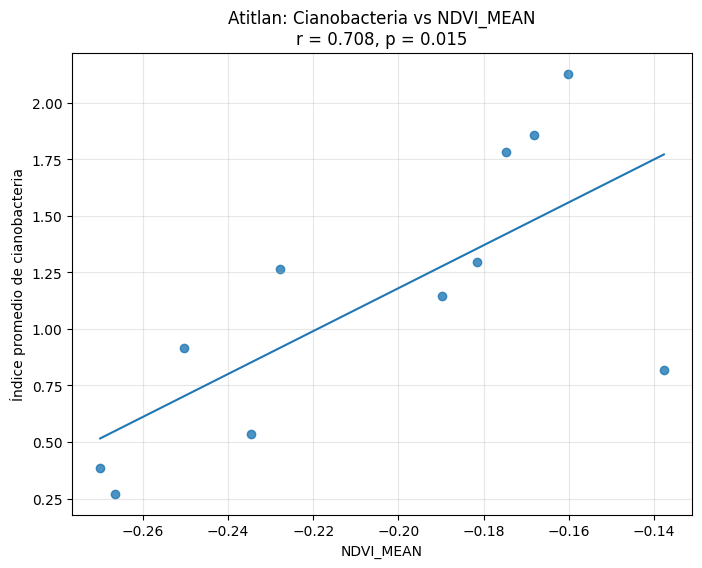

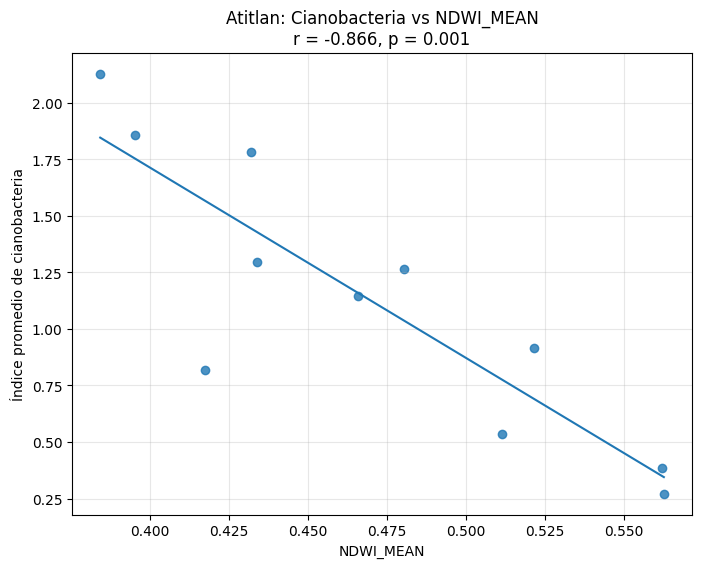

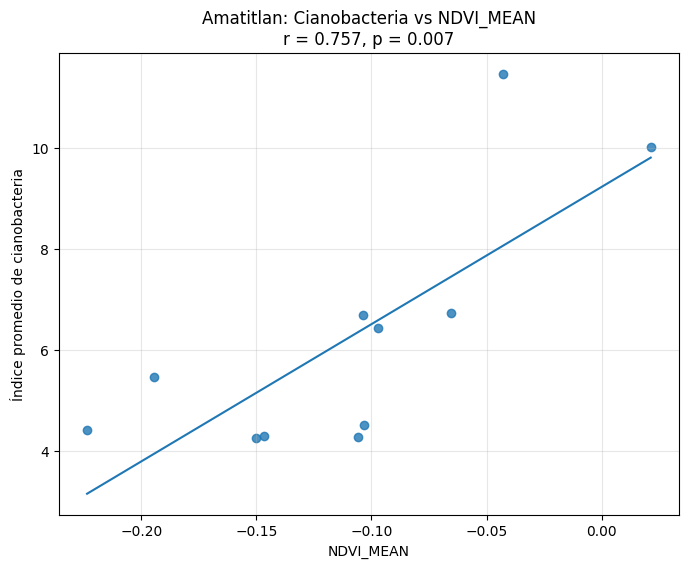

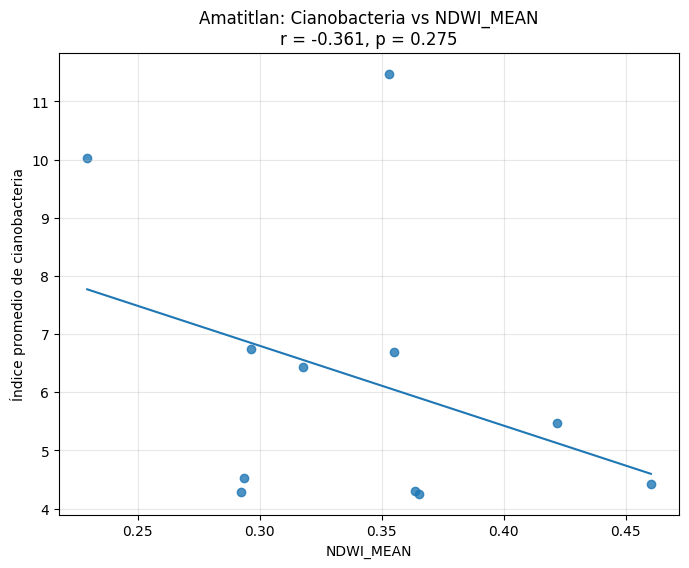

In [9]:
graficar_correlacion(df_indices, "Atitlan", "ndvi_mean")
graficar_correlacion(df_indices, "Atitlan", "ndwi_mean")

graficar_correlacion(df_indices, "Amatitlan", "ndvi_mean")
graficar_correlacion(df_indices, "Amatitlan", "ndwi_mean")

### Conclusiones
El NDVI promedio mostró tener correlaciones fuertes positivas, tanto de pearson como de spearman, respecto al índice promedio de cianobacterias, esto puede deberse a que ambos usan la banda 04. Además, los valores p de ambos índices son menores a 0.05, por lo que son significativos. Esto puede indicar que se refleja mucho la banda 08 y 03 y poco la 04.  

El NDWI promedio mostró tener correlaciones negativas, tanto de pearson como de spearman, respecto al índice promedio de cianobacterias, para el lago de Atitlán mostró una correlación fuerte y significativa y para el de Amatitlán mostró una correlación débil y no significativa para un alfa de 0.05. Esta correlación negativa débil en el de Amatitlán, puede deberse a la turbidez del lago, lo cual puede estar absorbiento la banda 03, evitando que refleje.  
